# Wine Dataset EDA 실습

이 노트북은 붓꽃 EDA에서 배운 흐름을 와인 데이터에 적용한 결과입니다. 데이터의 구조와 품질을 확인하고, 와인 종류별 특징 차이와 변수 사이의 관계를 시각화합니다.

**분석 흐름:** 데이터 불러오기 → 구조 확인 → 결측치·중복 확인 → 클래스 확인 → 기술통계 → 분포 비교 → 상관관계 → 이상치 탐지 → EDA 해석

## 1. 필요한 라이브러리 불러오기

`pandas`는 표 형태의 데이터 처리, `matplotlib`과 `seaborn`은 시각화, `sklearn`은 예제 와인 데이터를 불러오는 데 사용합니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.datasets import load_wine

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## 2. 데이터 불러오기

Google Colab에서 `wine.csv`를 업로드했다면 현재 폴더의 파일을 사용합니다. 파일이 없을 때는 `scikit-learn`에 포함된 Wine 데이터셋을 자동으로 불러오므로 노트북을 바로 실행할 수도 있습니다.

In [2]:
# Colab에서 파일을 선택하려면 아래 두 줄의 주석을 해제합니다.
# from google.colab import files
# files.upload()

local_path = Path("wine.csv")
if local_path.exists():
    df = pd.read_csv(local_path)
    print(f"업로드한 파일을 사용합니다: {local_path}")
else:
    wine = load_wine(as_frame=True)
    df = wine.frame.copy()
    df = df.rename(columns={"target": "wine_class"})
    print("wine.csv가 없어 sklearn 내장 Wine 데이터를 사용합니다.")

df.head()

wine.csv가 없어 sklearn 내장 Wine 데이터를 사용합니다.


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,wine_class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


## 3. 데이터 구조 확인

행과 열의 개수, 변수 이름, 자료형을 확인하여 이후 분석에 사용할 수치형 변수와 분류 레이블을 구분합니다.

In [3]:
print("데이터 크기:", df.shape)
print("\n처음 5개 데이터")
display(df.head())
print("\n변수 이름")
print(df.columns.tolist())
print("\n자료형")
print(df.dtypes)
print("\n데이터 정보")
df.info()

데이터 크기: (178, 14)

처음 5개 데이터


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,wine_class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0



변수 이름
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline', 'wine_class']

자료형
alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
wine_class                        int64
dtype: object

데이터 정보
<class 'pandas.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                  

## 4. 결측치와 중복 데이터 확인

결측치와 중복 행은 통계량과 시각화에 영향을 줄 수 있으므로 분석 전에 확인합니다.

In [4]:
print("변수별 결측치 개수")
print(df.isnull().sum())
print("\n중복 행 개수")
print(df.duplicated().sum())

변수별 결측치 개수
alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
wine_class                      0
dtype: int64

중복 행 개수
0


## 5. 분석 변수 지정

Wine 데이터의 `wine_class`는 와인 종류를 나타내는 레이블이고, 나머지 열은 화학적 측정값입니다. 업로드한 CSV의 레이블 열 이름이 다르면 아래 `target_col`만 수정하면 됩니다.

In [5]:
target_candidates = ["wine_class", "Wine", "target"]
target_col = next((col for col in target_candidates if col in df.columns), None)
if target_col is None:
    raise ValueError(f"레이블 열을 찾을 수 없습니다. 다음 중 하나가 필요합니다: {target_candidates}")
numeric_cols = [col for col in df.columns if col != target_col and pd.api.types.is_numeric_dtype(df[col])]

print("분석 대상 수치형 변수 수:", len(numeric_cols))
print(numeric_cols)

분석 대상 수치형 변수 수: 13
['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']


## 6. 와인 종류별 개수 확인

클래스별 데이터 수를 비교하여 클래스 불균형 여부를 확인합니다.

와인 종류
[0 1 2]

와인 종류별 개수
wine_class
0    59
1    71
2    48
Name: count, dtype: int64


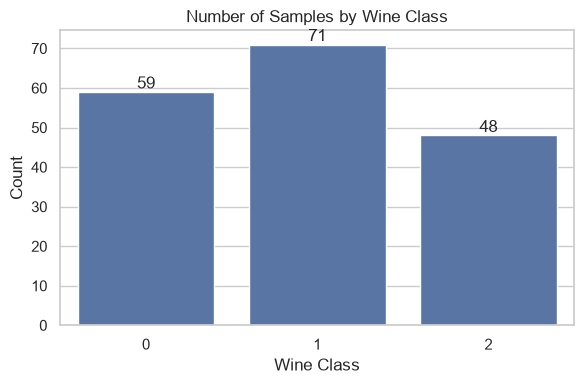

In [6]:
print("와인 종류")
print(df[target_col].unique())
print("\n와인 종류별 개수")
print(df[target_col].value_counts().sort_index())

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x=target_col, order=sorted(df[target_col].unique()))
for container in ax.containers:
    ax.bar_label(container)
plt.title("Number of Samples by Wine Class")
plt.xlabel("Wine Class")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 7. 기술통계량 확인

평균, 표준편차, 사분위수, 최솟값과 최댓값을 확인합니다. 변수마다 측정 단위와 값의 범위가 다를 수 있다는 점도 함께 살펴봅니다.

In [7]:
display(df[numeric_cols].describe().T.round(3))

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.001,0.812,11.03,12.362,13.050,13.678,14.83
malic_acid,178.0,2.336,1.117,0.74,1.602,1.865,3.082,5.80
ash,178.0,2.367,0.274,1.36,2.210,2.360,2.558,3.23
alcalinity_of_ash,178.0,19.495,3.340,10.60,17.200,19.500,21.500,30.00
magnesium,178.0,99.742,14.282,70.00,88.000,98.000,107.000,162.00
total_phenols,178.0,2.295,0.626,0.98,1.742,2.355,2.800,3.88
flavanoids,178.0,2.029,0.999,0.34,1.205,2.135,2.875,5.08
nonflavanoid_phenols,178.0,0.362,0.124,0.13,0.270,0.340,0.438,0.66
proanthocyanins,178.0,1.591,0.572,0.41,1.250,1.555,1.950,3.58
color_intensity,178.0,5.058,2.318,1.28,3.220,4.690,6.200,13.00


## 8. 와인 종류별 평균과 표준편차

그룹별 평균 차이가 큰 변수는 와인 종류를 구분하는 데 유용할 가능성이 있습니다.

In [8]:
print("와인 종류별 평균")
display(df.groupby(target_col)[numeric_cols].mean().round(3))
print("와인 종류별 표준편차")
display(df.groupby(target_col)[numeric_cols].std().round(3))

와인 종류별 평균


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
wine_class,,,,,,,,,,,,,
0,13.745,2.011,2.456,17.037,106.339,2.840,2.982,0.290,1.899,5.528,1.062,3.158,1115.712
1,12.279,1.933,2.245,20.238,94.549,2.259,2.081,0.364,1.630,3.087,1.056,2.785,519.507
2,13.154,3.334,2.437,21.417,99.312,1.679,0.781,0.448,1.154,7.396,0.683,1.684,629.896


와인 종류별 표준편차


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
wine_class,,,,,,,,,,,,,
0,0.462,0.689,0.227,2.546,10.499,0.339,0.397,0.070,0.412,1.239,0.116,0.357,221.521
1,0.538,1.016,0.315,3.350,16.753,0.545,0.706,0.124,0.602,0.925,0.203,0.497,157.211
2,0.530,1.088,0.185,2.258,10.890,0.357,0.294,0.124,0.409,2.311,0.114,0.272,115.097


## 9. 각 변수의 전체 분포

히스토그램과 KDE 곡선으로 각 화학적 측정값의 분포를 확인합니다.

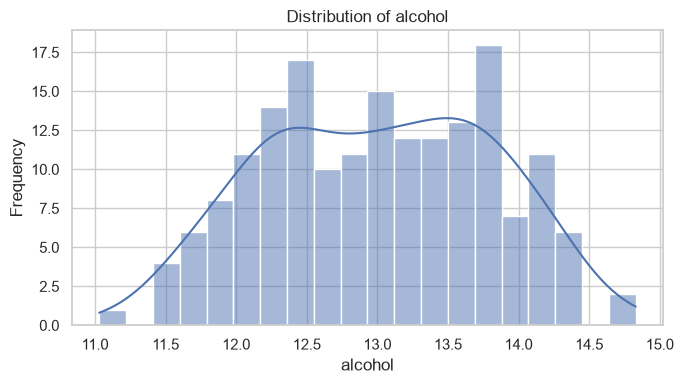

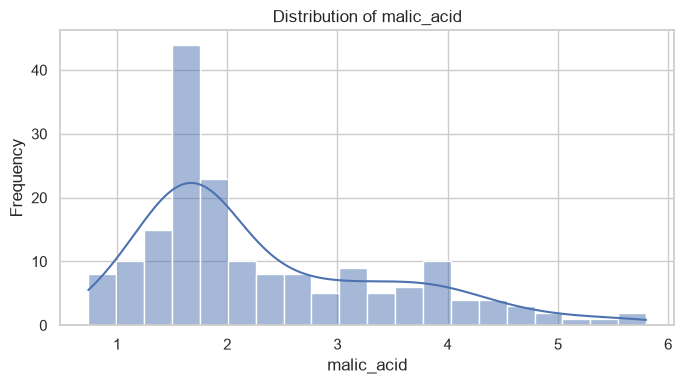

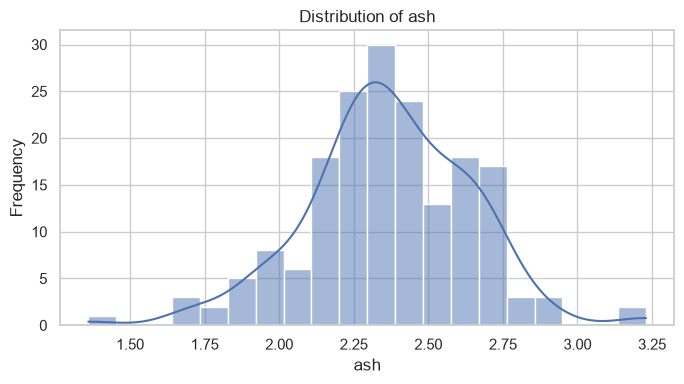

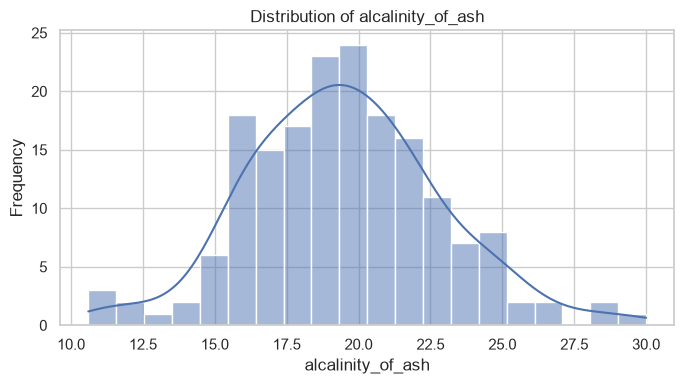

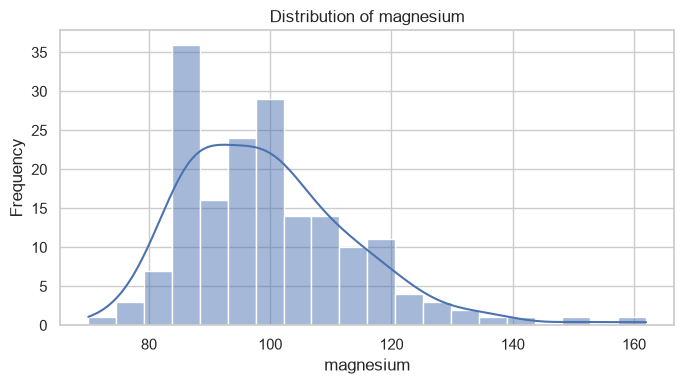

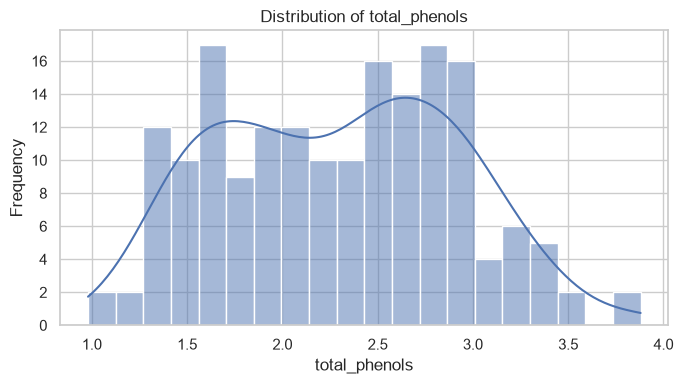

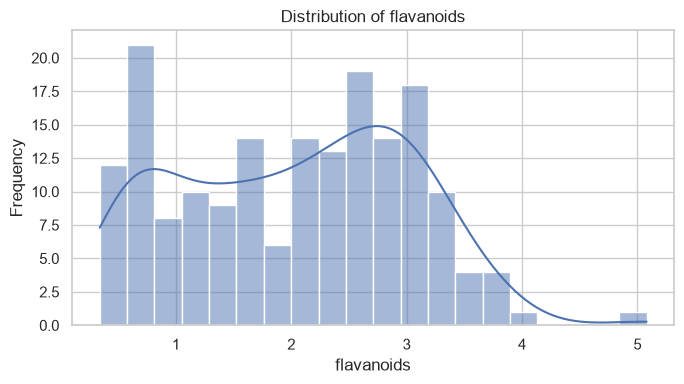

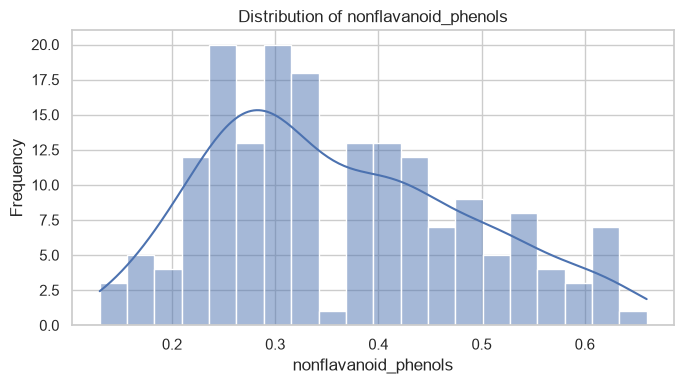

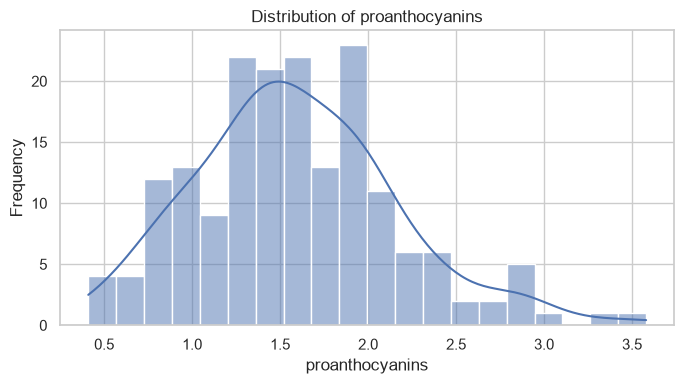

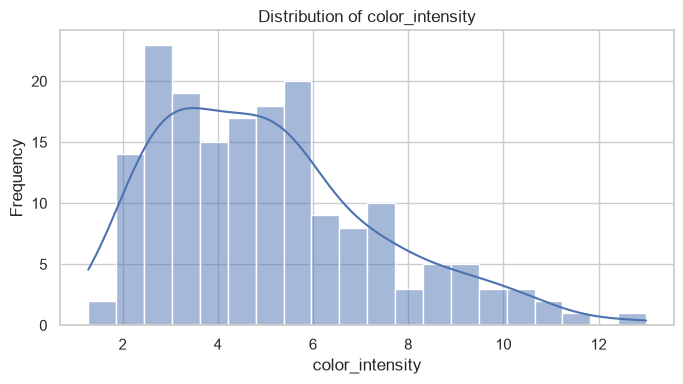

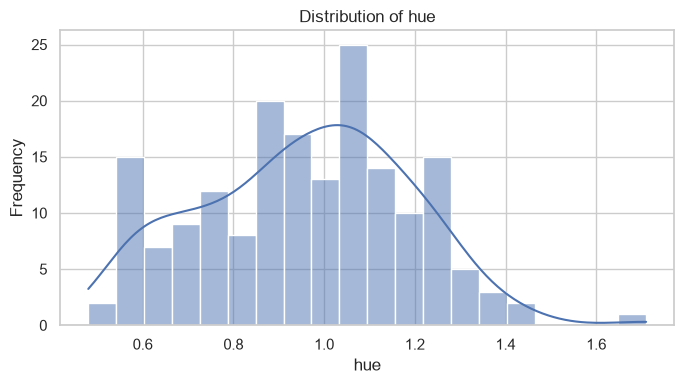

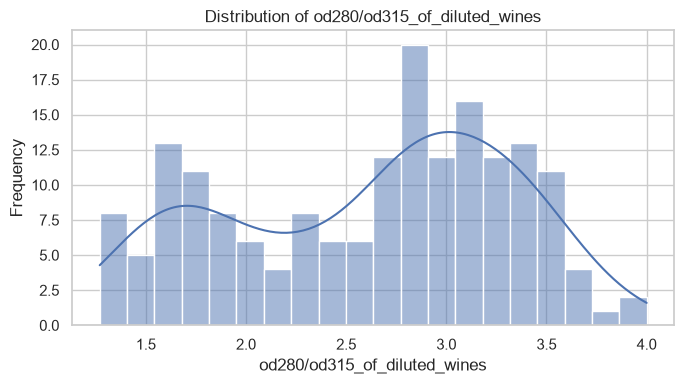

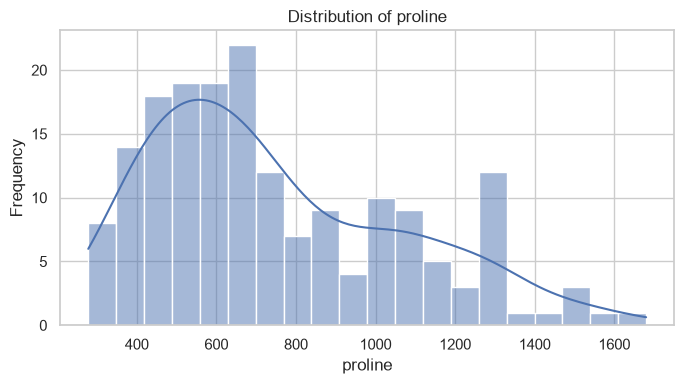

In [9]:
for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=df, x=col, bins=20, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

## 10. 와인 종류별 변수 분포 비교

같은 변수에서 와인 종류별 분포를 겹쳐 그려 클래스 간 차이를 확인합니다.

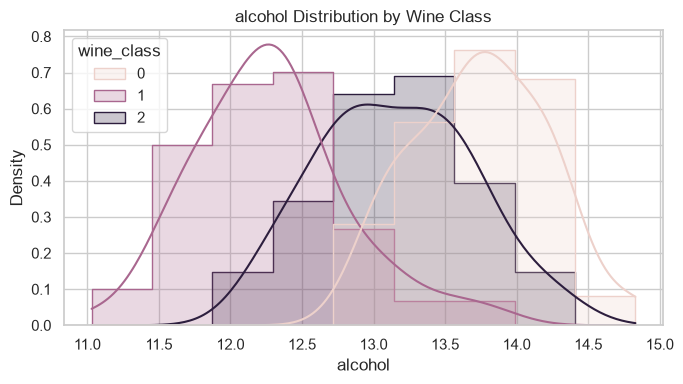

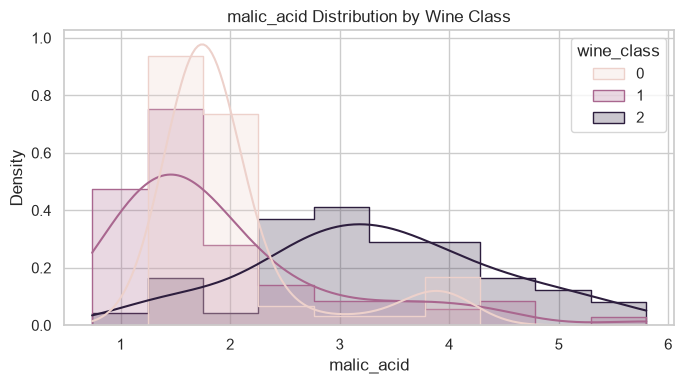

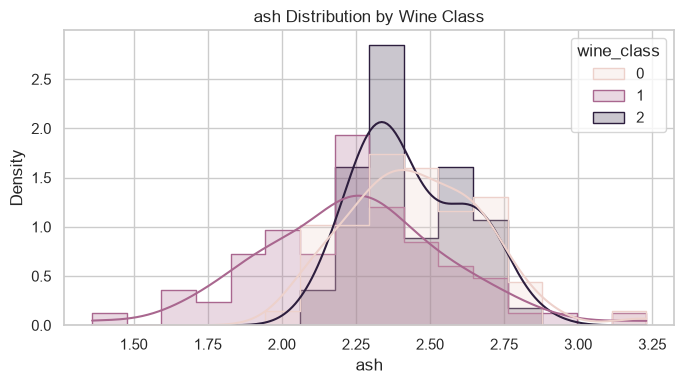

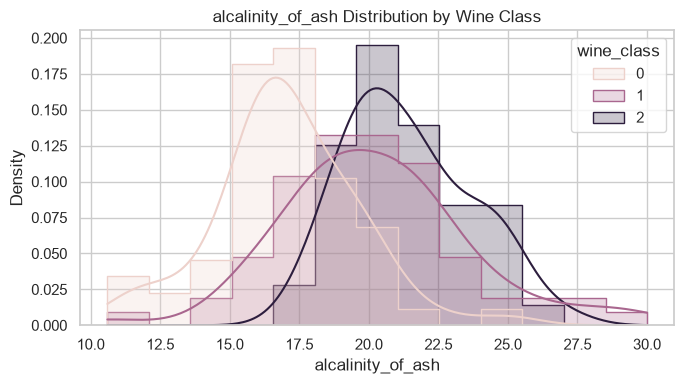

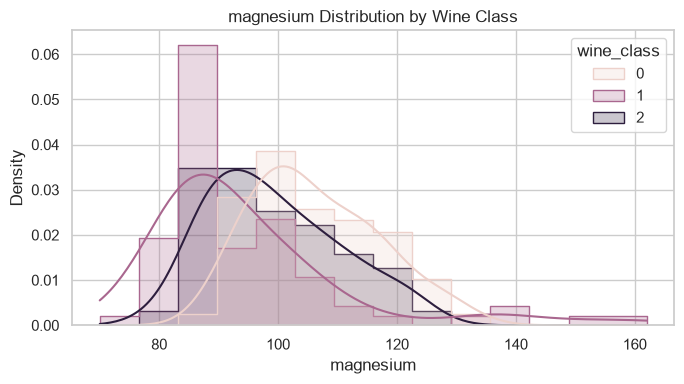

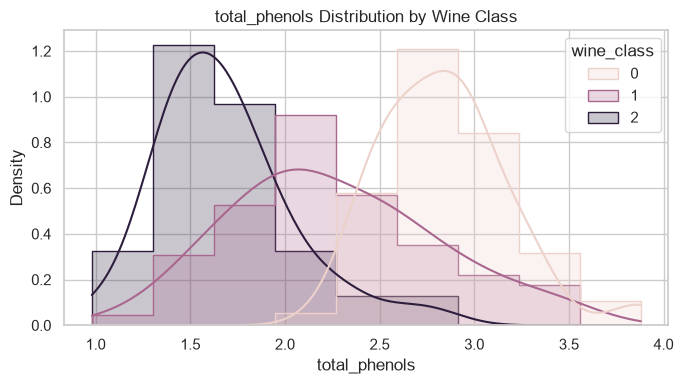

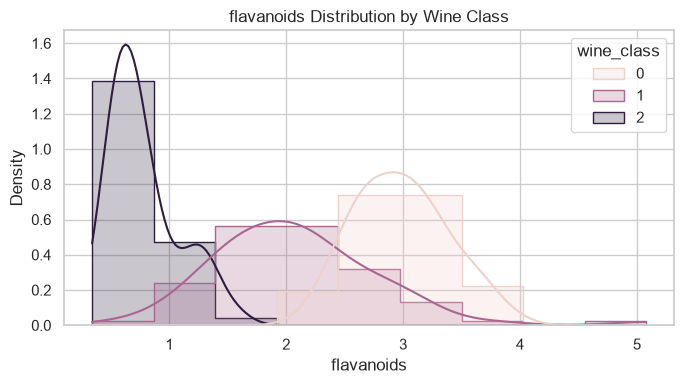

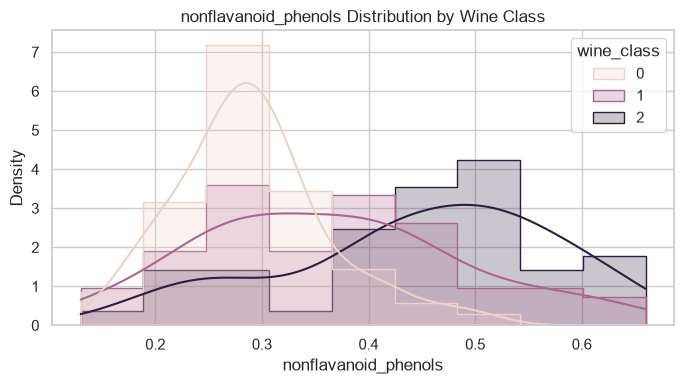

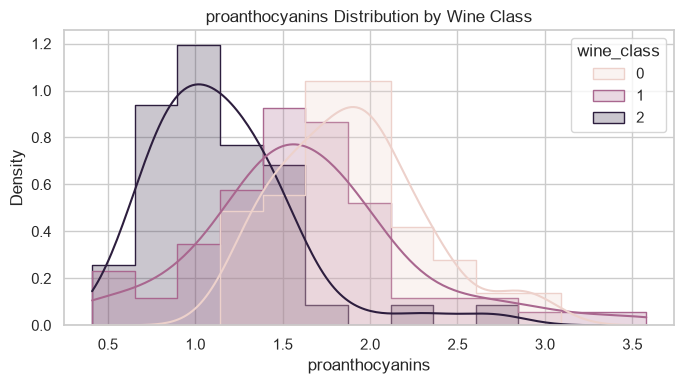

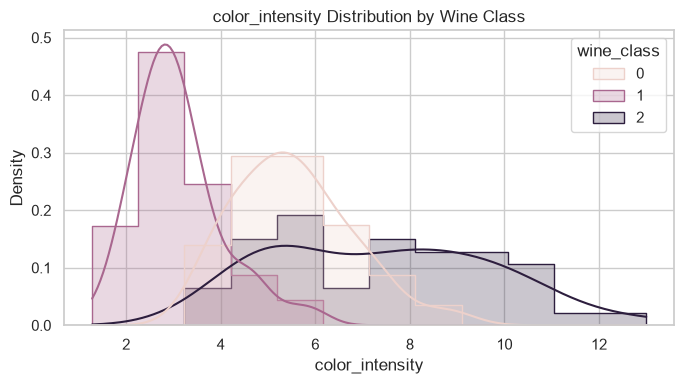

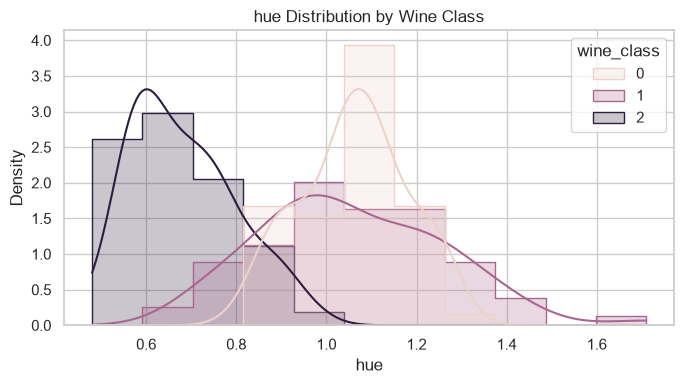

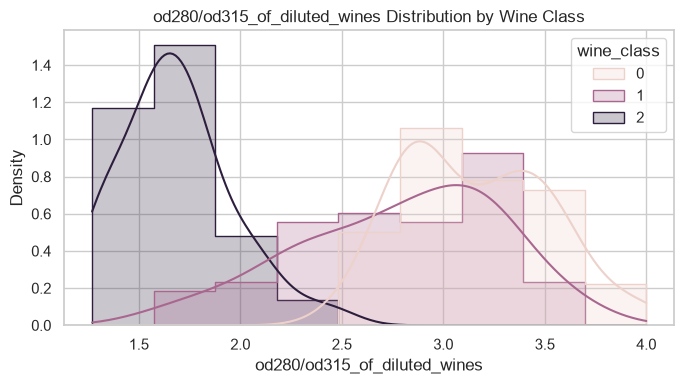

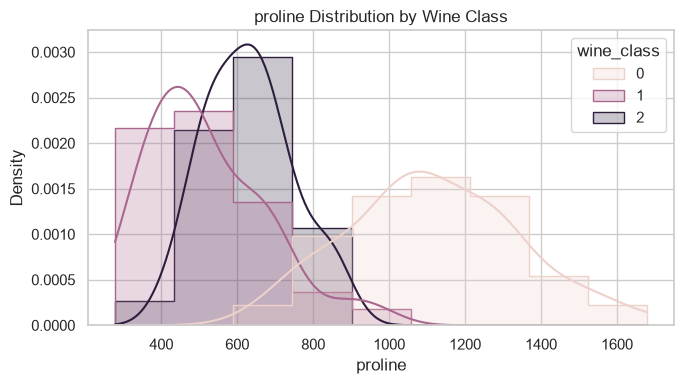

In [10]:
for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=df, x=col, hue=target_col, kde=True, element="step",
                 stat="density", common_norm=False)
    plt.title(f"{col} Distribution by Wine Class")
    plt.tight_layout()
    plt.show()

## 11. Box Plot과 Violin Plot

Box Plot은 중앙값·사분위수·이상치를, Violin Plot은 분포의 밀도를 보여줍니다. 변수별로 클래스의 중심과 퍼짐이 어떻게 다른지 비교합니다.

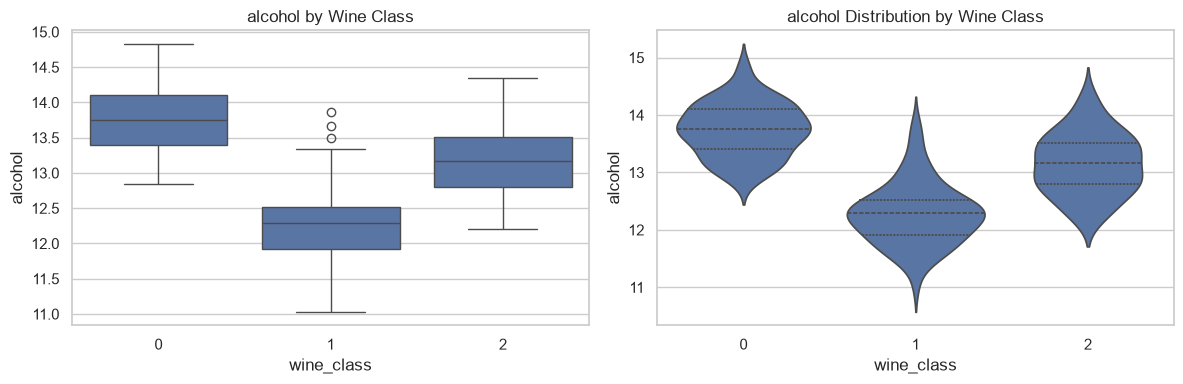

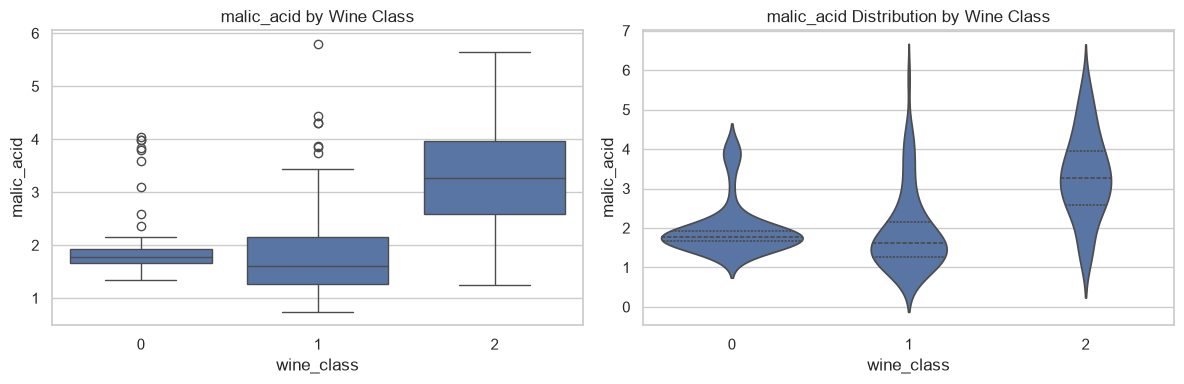

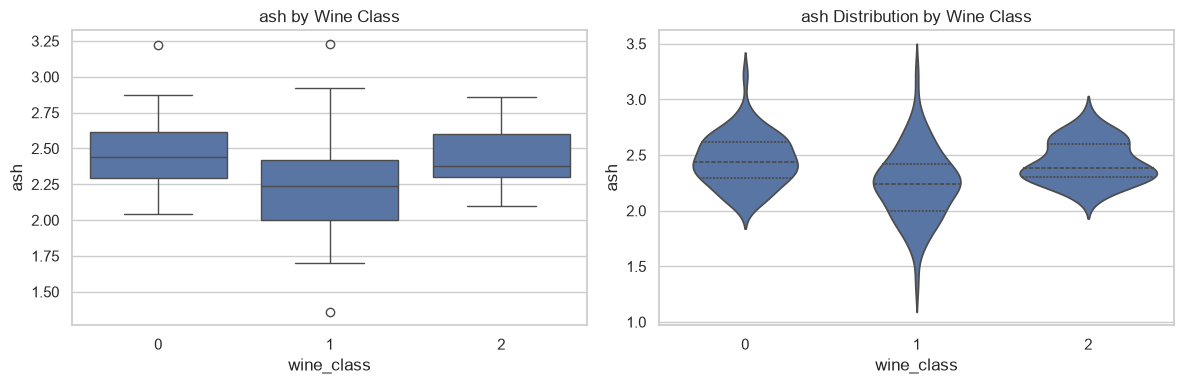

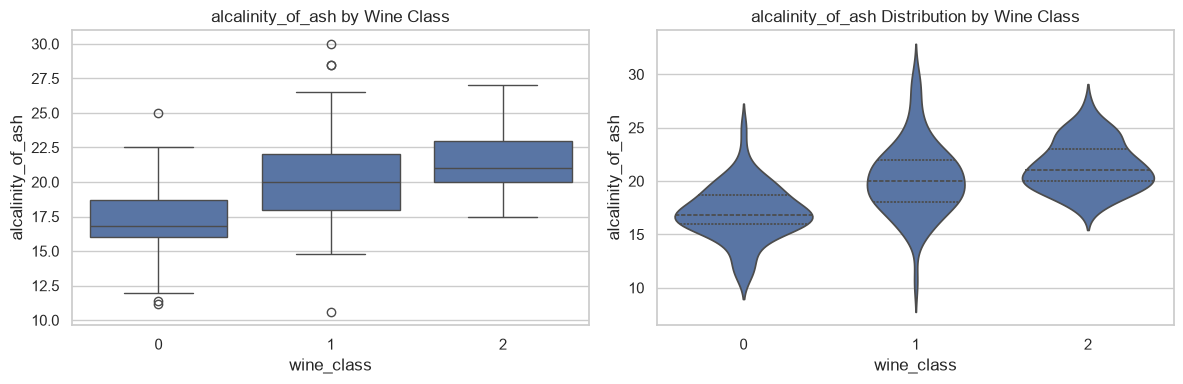

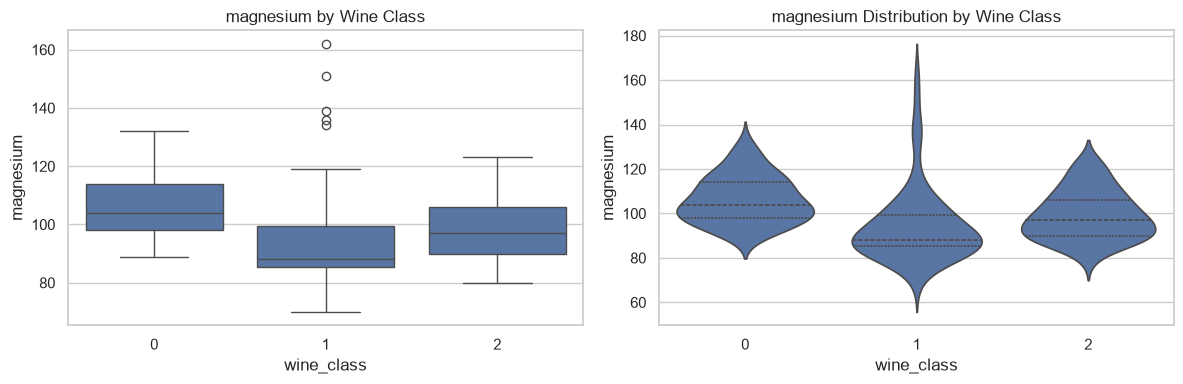

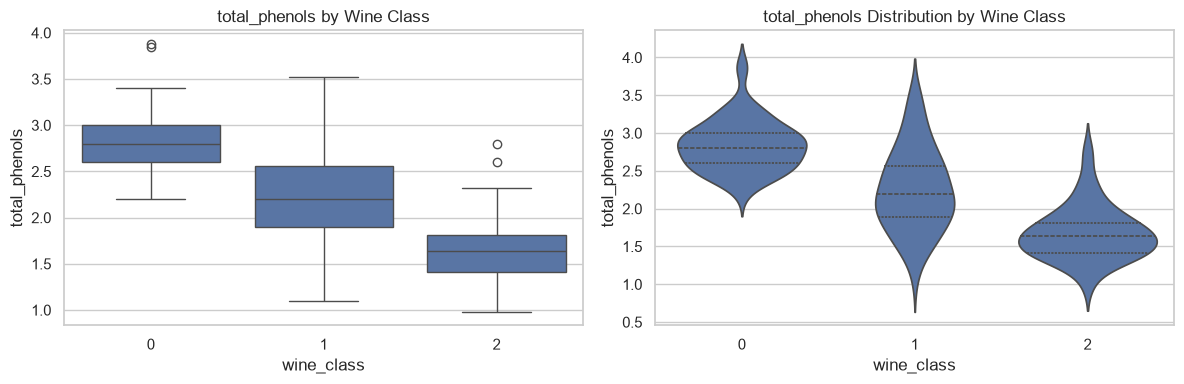

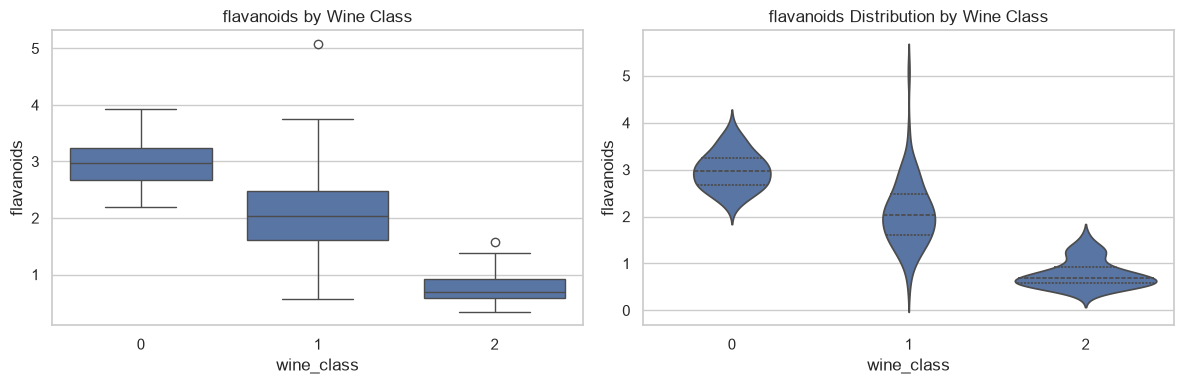

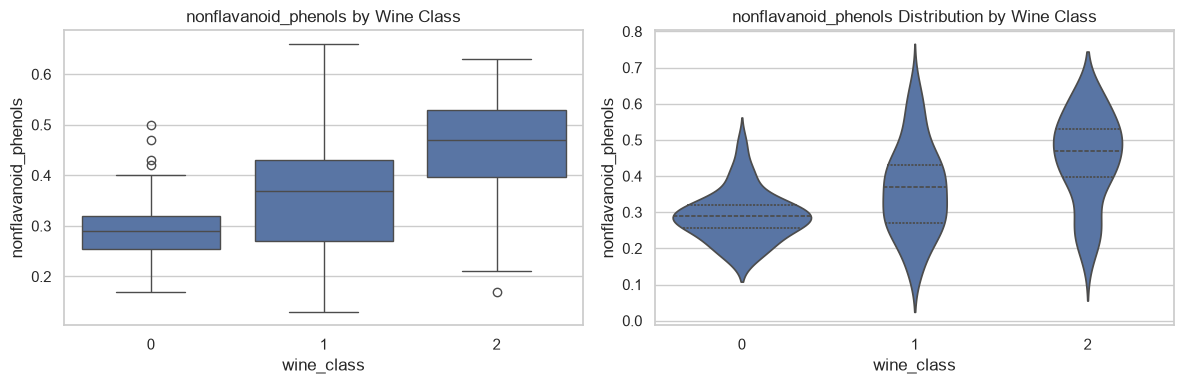

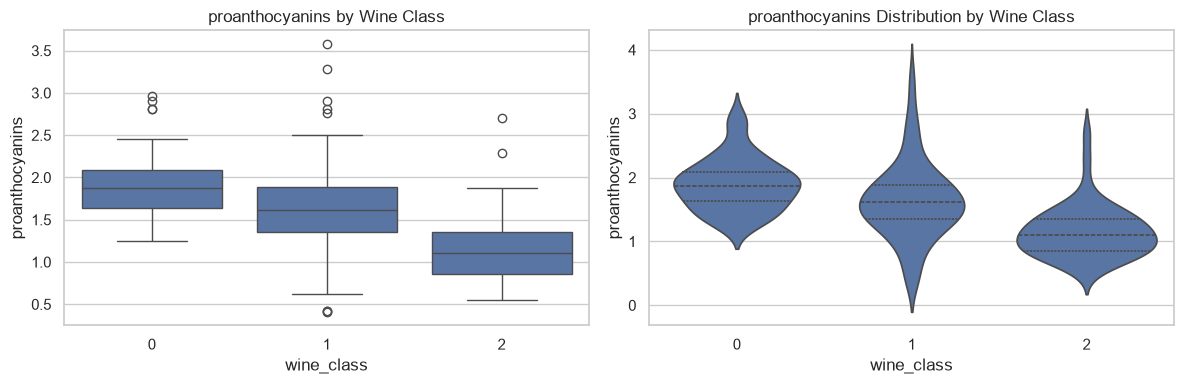

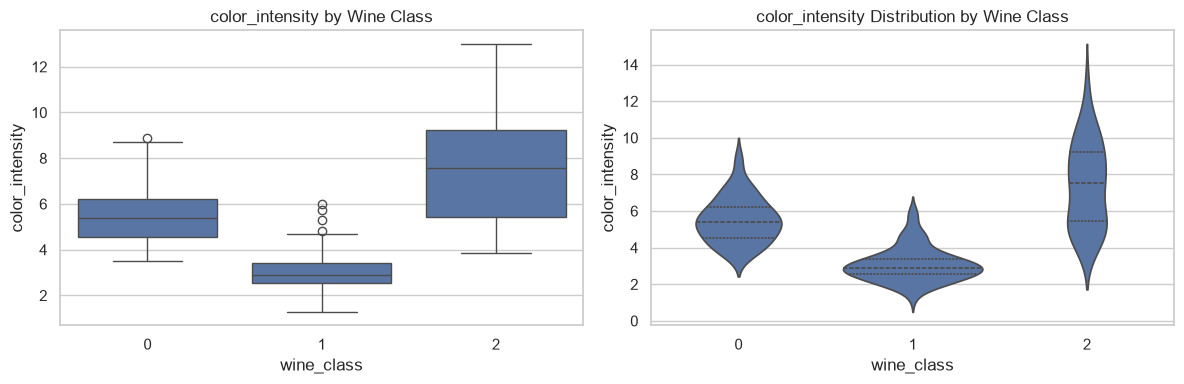

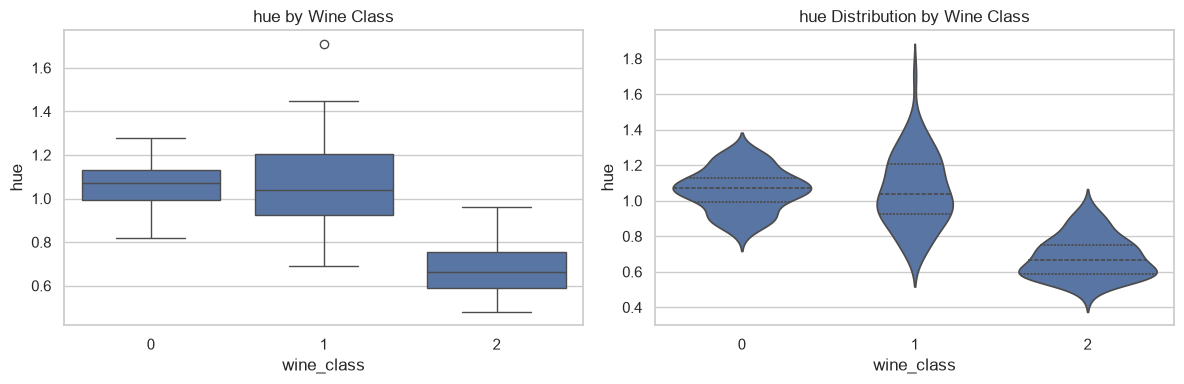

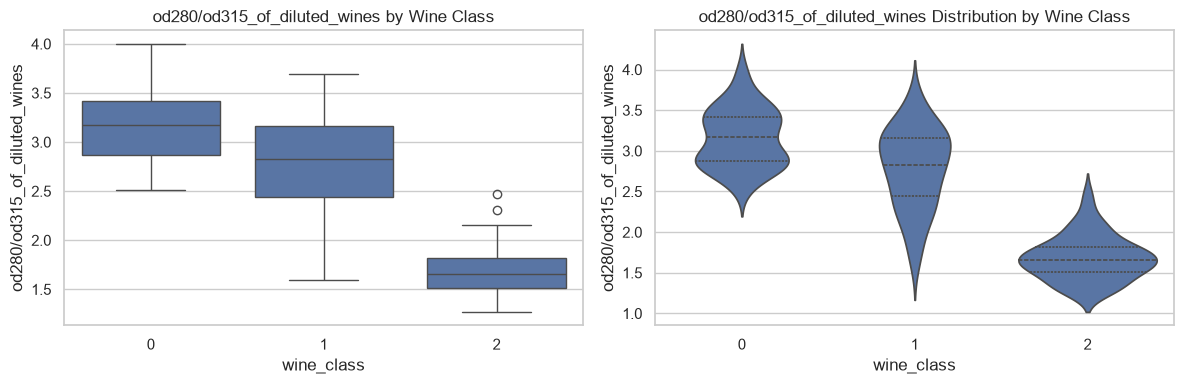

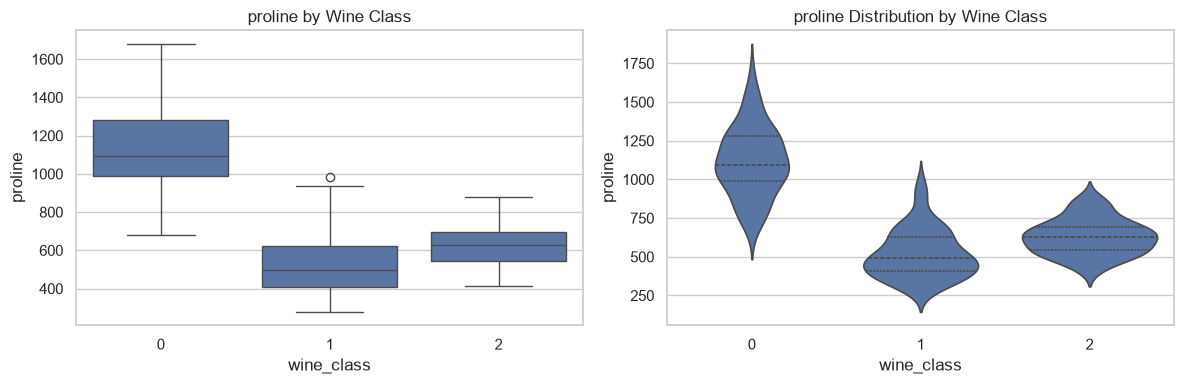

In [11]:
for col in numeric_cols:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.boxplot(data=df, x=target_col, y=col, ax=axes[0])
    axes[0].set_title(f"{col} by Wine Class")
    sns.violinplot(data=df, x=target_col, y=col, inner="quartile", ax=axes[1])
    axes[1].set_title(f"{col} Distribution by Wine Class")
    plt.tight_layout()
    plt.show()

## 12. 주요 변수 Pair Plot

모든 변수를 한 번에 그리면 그림이 복잡해질 수 있으므로, 클래스 분리에 특히 유용한 변수 후보를 평균 차이로 골라 관계를 확인합니다.

Pair Plot에 사용할 변수: ['proline', 'magnesium', 'alcalinity_of_ash', 'color_intensity']


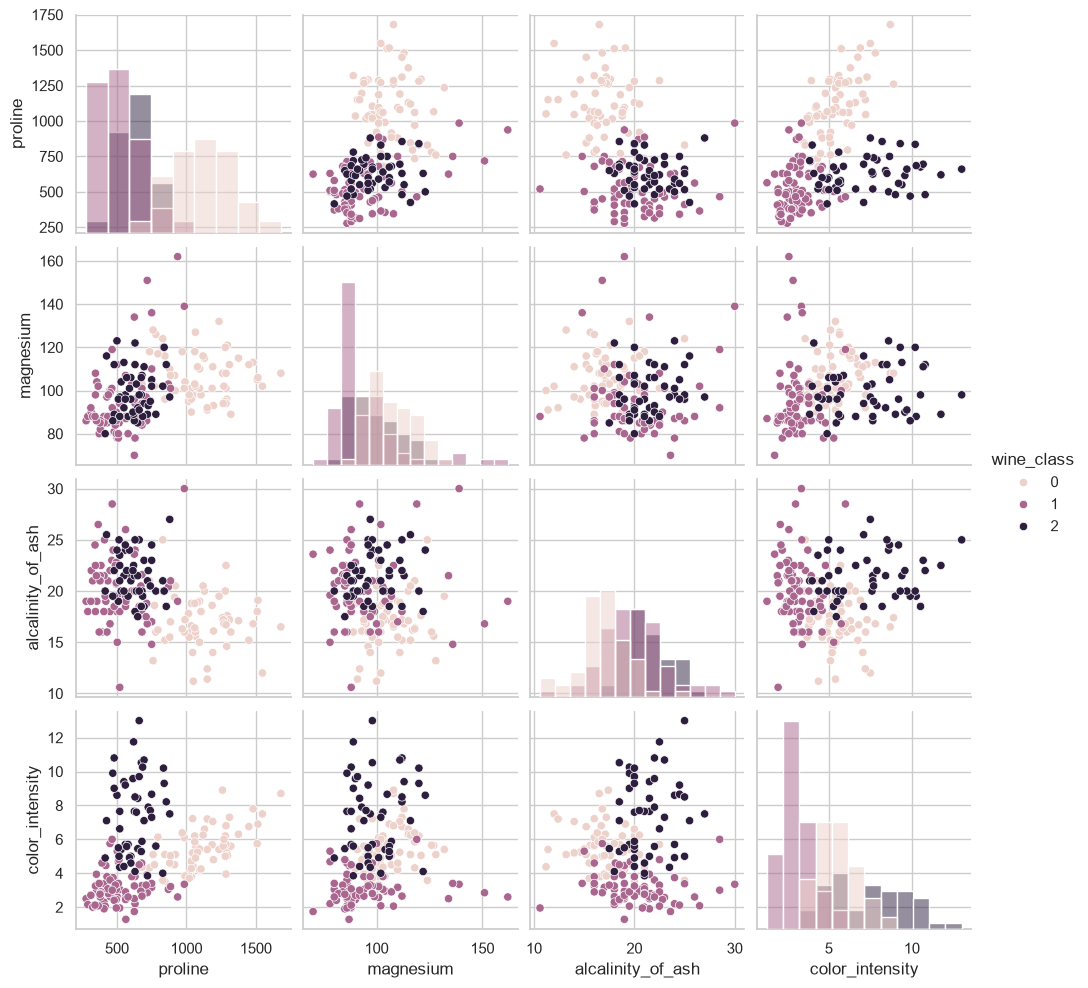

In [12]:
group_means = df.groupby(target_col)[numeric_cols].mean()
feature_spread = (group_means.max() - group_means.min()).sort_values(ascending=False)
plot_cols = feature_spread.head(min(4, len(feature_spread))).index.tolist()
print("Pair Plot에 사용할 변수:", plot_cols)
sns.pairplot(df, vars=plot_cols, hue=target_col, diag_kind="hist")
plt.show()

## 13. 변수 간 상관관계 분석

상관계수는 두 수치형 변수 사이의 선형 관계를 나타냅니다. 상관관계가 높다고 해서 인과관계를 의미하는 것은 아닙니다.

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
alcohol,1.000,0.094,0.212,-0.310,0.271,0.289,0.237,-0.156,0.137,0.546,-0.072,0.072,0.644
malic_acid,0.094,1.000,0.164,0.289,-0.055,-0.335,-0.411,0.293,-0.221,0.249,-0.561,-0.369,-0.192
ash,0.212,0.164,1.000,0.443,0.287,0.129,0.115,0.186,0.010,0.259,-0.075,0.004,0.224
alcalinity_of_ash,-0.310,0.289,0.443,1.000,-0.083,-0.321,-0.351,0.362,-0.197,0.019,-0.274,-0.277,-0.441
magnesium,0.271,-0.055,0.287,-0.083,1.000,0.214,0.196,-0.256,0.236,0.200,0.055,0.066,0.393
total_phenols,0.289,-0.335,0.129,-0.321,0.214,1.000,0.865,-0.450,0.612,-0.055,0.434,0.700,0.498
flavanoids,0.237,-0.411,0.115,-0.351,0.196,0.865,1.000,-0.538,0.653,-0.172,0.543,0.787,0.494
nonflavanoid_phenols,-0.156,0.293,0.186,0.362,-0.256,-0.450,-0.538,1.000,-0.366,0.139,-0.263,-0.503,-0.311
proanthocyanins,0.137,-0.221,0.010,-0.197,0.236,0.612,0.653,-0.366,1.000,-0.025,0.296,0.519,0.330
color_intensity,0.546,0.249,0.259,0.019,0.200,-0.055,-0.172,0.139,-0.025,1.000,-0.522,-0.429,0.316


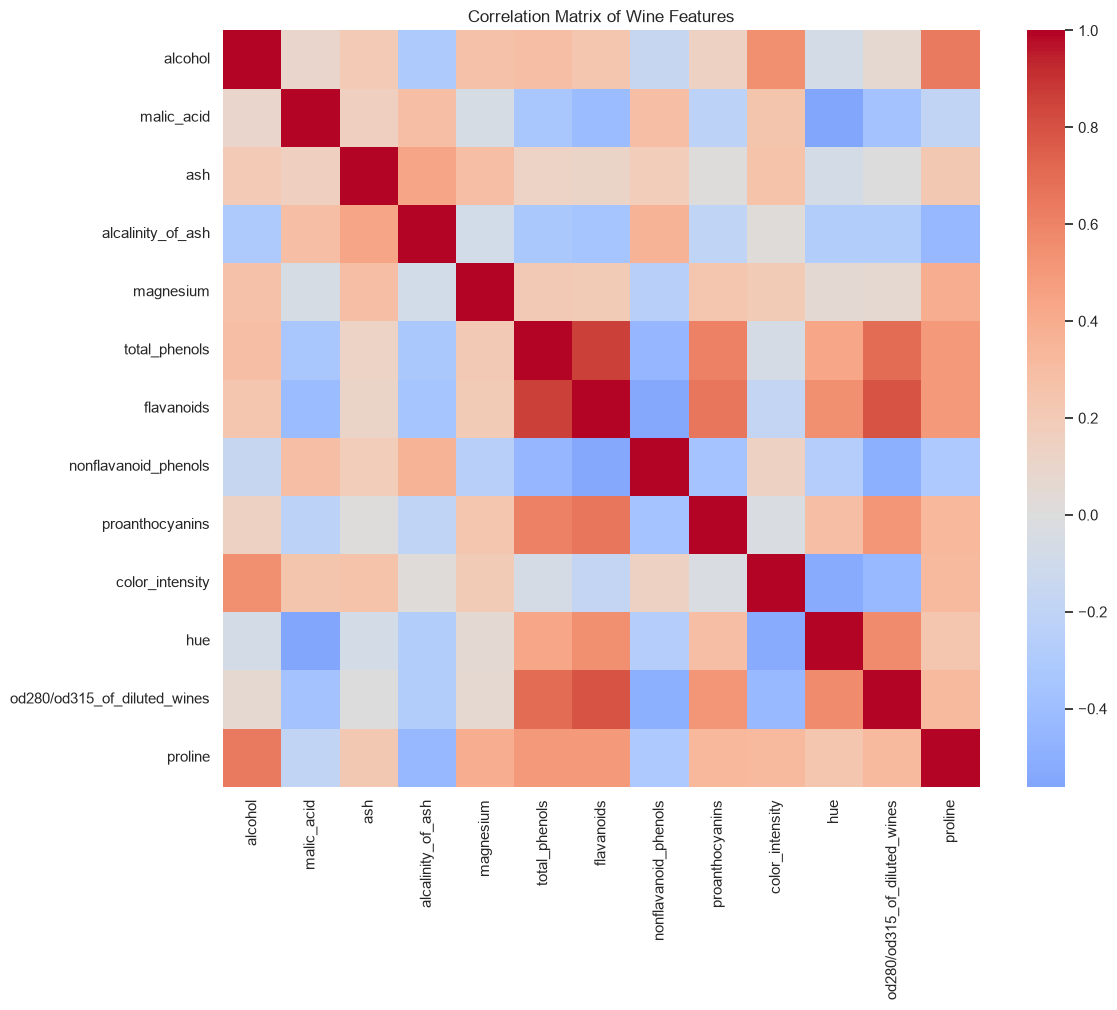

In [13]:
corr = df[numeric_cols].corr()
display(corr.round(3))

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, square=True)
plt.title("Correlation Matrix of Wine Features")
plt.tight_layout()
plt.show()

## 14. 주요 변수 산점도

클래스별 평균 차이가 큰 두 변수를 선택하여 와인 종류가 산점도에서 얼마나 구분되는지 확인합니다.

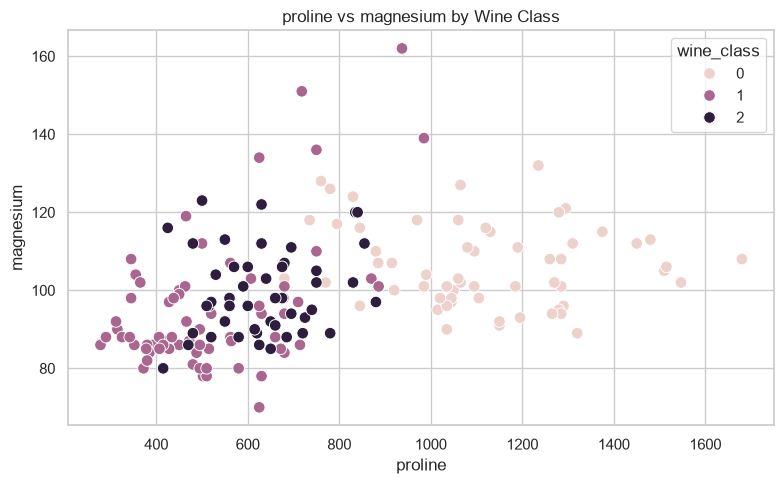

In [14]:
x_col, y_col = plot_cols[:2]
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x=x_col, y=y_col, hue=target_col, s=70)
plt.title(f"{x_col} vs {y_col} by Wine Class")
plt.tight_layout()
plt.show()

## 15. IQR을 이용한 이상치 탐지

`Q1 - 1.5×IQR`보다 작거나 `Q3 + 1.5×IQR`보다 큰 값을 이상치 후보로 표시합니다. 탐지된 값이라고 해서 무조건 삭제하지 않고, 실제 측정 오류인지 정상적인 극단값인지 추가로 판단해야 합니다.

In [15]:
outlier_summary = []
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    mask = (df[col] < lower) | (df[col] > upper)
    outlier_summary.append({
        "feature": col,
        "outlier_count": int(mask.sum()),
        "lower_bound": lower,
        "upper_bound": upper,
    })

outlier_summary = pd.DataFrame(outlier_summary)
display(outlier_summary.round(3))

,feature,outlier_count,lower_bound,upper_bound
0,alcohol,0,10.390,15.650
1,malic_acid,3,-0.617,5.302
2,ash,3,1.689,3.079
3,alcalinity_of_ash,4,10.750,27.950
4,magnesium,4,59.500,135.500
5,total_phenols,0,0.156,4.386
6,flavanoids,0,-1.300,5.380
7,nonflavanoid_phenols,0,0.019,0.689
8,proanthocyanins,2,0.200,3.000
9,color_intensity,4,-1.250,10.670


## 16. 와인 종류별 평균값 비교

변수별 평균을 하나의 그래프로 비교하여 클래스별 특징 차이를 정리합니다.

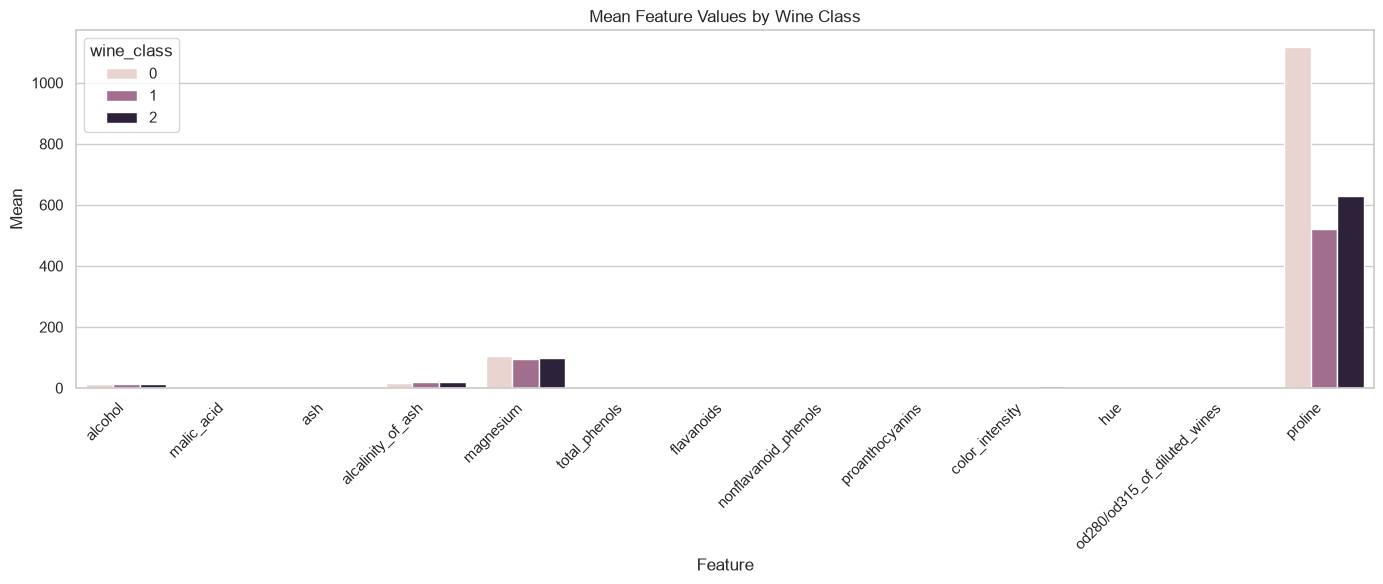

In [16]:
mean_long = (df.groupby(target_col)[numeric_cols].mean().reset_index()
              .melt(id_vars=target_col, var_name="Feature", value_name="Mean"))
plt.figure(figsize=(14, 6))
sns.barplot(data=mean_long, x="Feature", y="Mean", hue=target_col)
plt.title("Mean Feature Values by Wine Class")
plt.xlabel("Feature")
plt.ylabel("Mean")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 17. EDA 결과 해석

- Wine 데이터는 여러 화학적 측정값과 와인 종류 레이블로 구성됩니다.
- 클래스별 평균과 분포를 비교하면 종류에 따라 차이가 큰 변수를 찾을 수 있습니다.
- 상관관계가 높은 변수들은 비슷한 정보를 포함할 수 있으므로 모델링 전 변수 선택이나 차원 축소를 고려할 수 있습니다.
- IQR 이상치는 즉시 삭제하기보다 원자료의 의미와 측정 과정을 확인해야 합니다.

이번 분석에서는 붓꽃 데이터에서 사용한 EDA 절차를 와인 데이터의 변수 수와 특성에 맞게 확장했습니다.